# Trajectory Generator Evaluation — CFM vs Trapezoid Ground Truth

Evaluate three CFM models against rotate-then-translate trapezoid trajectories generated by `trajectory_generator3Dmultipleinit_npz.py`.

**Models**
1. **athit3D** — single model, (x, y, θ) output, 11-dim context
2. **athit3Dmultiinit** — single model, (x, y, θ) output, 13-dim context (adds `omega_const`, `alpha_const`)
3. **Composite (rotate-first → translate)** — two sub-models
   - 3a θ-only: `transition_dim=1`, 5-dim context `[s_goal_theta, v_const, accel, q_init_theta, qdot_init_theta]`
   - 3b xy: `transition_dim=2`, 8-dim context `[s_goal_x, s_goal_y, qdot_init_x, qdot_init_y, v_const, accel, q_init_x, q_init_y]`

**Evaluation method**
Plot 6 panels per sample comparing each model's generated trajectory to the ground-truth trapezoid:
x(t), y(t), θ(t), ẋ(t), ẏ(t), θ̇(t).

In [1]:
import os, sys, math
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'scripts' else Path.cwd()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
for p in (PROJECT_ROOT, SCRIPTS_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from diffuser.models.temporal_film import ConditionalUnet1D
from diffuser.models.cfm import CFM
from trajectory_generator3Dmultipleinit_npz import create_dataset, GeneratorConfig

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
HORIZON           = 64
ORIGINAL_LEN      = 50
N_SAMPLING_STEPS  = 10
SAMPLE_HZ         = 25.0
DT                = 1.0 / SAMPLE_HZ
print('device:', DEVICE)

device: cuda


In [2]:
CKPT_MODEL1     = PROJECT_ROOT / 'logs/pose_trajectory_3D/cfm/H64_T100/20260430-1155/state_192000.pt'
CKPT_MODEL2     = PROJECT_ROOT / 'logs/pose_trajectory_3D_multiinit/cfm/H64_T100/20260512-1337/state_192000.pt'
CKPT_MODEL3_XY  = PROJECT_ROOT / 'logs/pose_trajectory_athit_notrajpart/cfm/H64_T100/20260416-1405/state_192000.pt'
CKPT_MODEL3_TH  = PROJECT_ROOT / 'logs/pose_trajectory_athit_theta/cfm/H64_T100/20260428-1149/state_192000.pt'
for p in (CKPT_MODEL1, CKPT_MODEL2, CKPT_MODEL3_XY, CKPT_MODEL3_TH):
    print(('OK  ' if p.exists() else 'MISS'), p)

OK   /home/bubble/PhysicalAI_flowmatching/logs/pose_trajectory_3D/cfm/H64_T100/20260430-1155/state_192000.pt
OK   /home/bubble/PhysicalAI_flowmatching/logs/pose_trajectory_3D_multiinit/cfm/H64_T100/20260512-1337/state_192000.pt
OK   /home/bubble/PhysicalAI_flowmatching/logs/pose_trajectory_athit_notrajpart/cfm/H64_T100/20260416-1405/state_192000.pt
OK   /home/bubble/PhysicalAI_flowmatching/logs/pose_trajectory_athit_theta/cfm/H64_T100/20260428-1149/state_192000.pt


## 1. Generate evaluation dataset

In [3]:
EVAL_N_TRAJECTORIES = 50000   # one window per trajectory → 50 eval samples
EVAL_SEED           = 30
EVAL_N_PLOT         = 6    # number of windows to actually plot

cfg = GeneratorConfig(num_samples=EVAL_N_TRAJECTORIES, seed=EVAL_SEED)
features_raw, targets_raw, feature_names = create_dataset(cfg)

# Keep only the first window per trajectory (start=0 → t_init=0). No slicing.
T_INIT_COL = list(feature_names).index('t_init')
mask = features_raw[:, T_INIT_COL] == 0
features_np = features_raw[mask].astype(np.float32)
targets_np  = targets_raw[mask].astype(np.float32)

print(f'raw windows from generator : {features_raw.shape[0]}')
print(f'kept (t_init==0 only)      : {features_np.shape[0]}')
print('features:', features_np.shape, '|', list(feature_names))
print('targets :', targets_np.shape, '   (N, 50, [x, y, theta])')


raw windows from generator : 807390
kept (t_init==0 only)      : 50000
features: (50000, 14) | ['s_goal_x', 's_goal_y', 's_goal_theta', 'v_const', 'accel', 'omega_const', 'alpha_const', 'q_init_x', 'q_init_y', 'q_init_theta', 'qdot_init_x', 'qdot_init_y', 'qdot_init_theta', 't_init']
targets : (50000, 50, 3)    (N, 50, [x, y, theta])


## 2. Model loaders

Each loader builds the same `ConditionalUnet1D` + `CFM` wrapper and remaps checkpoint keys `node.vf.vf.*` → `model.*`.

In [4]:
def build_cfm(transition_dim: int, context_dim: int) -> CFM:
    model = ConditionalUnet1D(
        horizon=HORIZON,
        transition_dim=transition_dim,
        lstm_in_dim=None,
        lstm_out_dim=None,
        global_cond_dim=context_dim,
        cond_dim=transition_dim,
        dim_mults=(1, 4, 8),
    ).to(DEVICE)
    return CFM(
        model=model,
        horizon=HORIZON,
        observation_dim=transition_dim,
        action_dim=0,
        n_timesteps=N_SAMPLING_STEPS,
        loss_type='l2',
        predict_epsilon=False,
    ).to(DEVICE)


def load_ckpt_into(diffusion: CFM, ckpt_path: Path) -> CFM:
    raw = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)['model']
    # CFM exposes the same params under both 'model.*' and 'node.vf.vf.*';
    # checkpoints contain both copies so strict=False is safe.
    missing, _ = diffusion.load_state_dict(raw, strict=False)
    truly_missing = [k for k in missing if not k.startswith(('model.', 'node.vf.vf.'))]
    if truly_missing:
        raise RuntimeError(f'Missing keys when loading {ckpt_path.name}: {truly_missing}')
    diffusion.eval()
    return diffusion


@torch.no_grad()
def cfm_sample(diffusion: CFM, ctx_np: np.ndarray) -> np.ndarray:
    """Vanilla CFM sampling — first timestep drifts away from q_init."""
    ctx = torch.tensor(ctx_np, dtype=torch.float32, device=DEVICE)
    B = ctx.shape[0]
    global_cond = {'hideouts': ctx}
    cond = [(np.array([]), np.array([]))] * B
    samples = diffusion.conditional_sample(global_cond, cond)
    return samples.cpu().numpy()[:, :ORIGINAL_LEN, :]


@torch.no_grad()
def cfm_sample_inpaint(diffusion: CFM, ctx_np: np.ndarray, init_np: np.ndarray) -> np.ndarray:
    """Euler ODE sampling with hard-anchored first timestep.

    After every Euler step we overwrite x[:, 0, :] with the ground-truth init.
    Mirrors how the controllers in scripts/evaluation_context*.py operate:
    each replan starts from the current pose, so x[0] is never free.

    ctx_np:  (B, ctx_dim)
    init_np: (B, transition_dim) — pinned to x[:, 0, :]
    """
    transition_dim = diffusion.observation_dim + diffusion.action_dim
    assert init_np.shape[1] == transition_dim, (
        f'init dim {init_np.shape[1]} != transition_dim {transition_dim}'
    )

    ctx  = torch.tensor(ctx_np,  dtype=torch.float32, device=DEVICE)
    init = torch.tensor(init_np, dtype=torch.float32, device=DEVICE)
    B = ctx.shape[0]
    shape = (B, HORIZON, transition_dim)
    global_cond = {'hideouts': ctx}

    x = torch.randn(shape, device=DEVICE)
    x[:, 0, :] = init

    ts = torch.linspace(0.0, 1.0, N_SAMPLING_STEPS + 1, device=DEVICE)
    for i in range(N_SAMPLING_STEPS):
        t  = ts[i]
        dt = ts[i + 1] - ts[i]
        v = diffusion.model.forward(t, x, global_cond=global_cond)
        x = x + dt * v
        x[:, 0, :] = init

    return x.cpu().numpy()[:, :ORIGINAL_LEN, :]


In [5]:
print('Loading model 1 (athit3D, 11-dim ctx, 3D out) ...')
diff_m1 = load_ckpt_into(build_cfm(transition_dim=3, context_dim=11), CKPT_MODEL1)

print('Loading model 2 (3D multiinit, 13-dim ctx, 3D out) ...')
diff_m2 = load_ckpt_into(build_cfm(transition_dim=3, context_dim=13), CKPT_MODEL2)

print('Loading model 3a (theta-only, 5-dim ctx, 1D out) ...')
diff_m3_theta = load_ckpt_into(build_cfm(transition_dim=1, context_dim=5), CKPT_MODEL3_TH)

print('Loading model 3b (xy translation, 8-dim ctx, 2D out) ...')
diff_m3_xy = load_ckpt_into(build_cfm(transition_dim=2, context_dim=8), CKPT_MODEL3_XY)

print('All models loaded.')

Loading model 1 (athit3D, 11-dim ctx, 3D out) ...
Loading model 2 (3D multiinit, 13-dim ctx, 3D out) ...
Loading model 3a (theta-only, 5-dim ctx, 1D out) ...
Loading model 3b (xy translation, 8-dim ctx, 2D out) ...
All models loaded.


## 3. Context builders

Slice the 14-column feature row from the generator into each model's required context layout.

In [6]:
# feature_names order:
#  0 s_goal_x       7 q_init_x        10 qdot_init_x
#  1 s_goal_y       8 q_init_y        11 qdot_init_y
#  2 s_goal_theta   9 q_init_theta    12 qdot_init_theta
#  3 v_const                          13 t_init
#  4 accel
#  5 omega_const
#  6 alpha_const

def ctx_model1(f: np.ndarray) -> np.ndarray:
    # [s_goal_xyθ, v_const, accel, q_init_xyθ, qdot_init_xyθ]
    cols = [0, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12]
    return f[:, cols]

def ctx_model2(f: np.ndarray) -> np.ndarray:
    # [s_goal_xyθ, v_const, accel, omega_const, alpha_const, q_init_xyθ, qdot_init_xyθ]
    cols = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    return f[:, cols]

def ctx_model3_theta(f: np.ndarray) -> np.ndarray:
    # [s_goal_theta, v_const, accel, q_init_theta, qdot_init_theta]
    cols = [2, 3, 4, 9, 12]
    return f[:, cols]

def ctx_model3_xy(f: np.ndarray) -> np.ndarray:
    # [s_goal_x, s_goal_y, qdot_init_x, qdot_init_y, v_const, accel, q_init_x, q_init_y]
    cols = [0, 1, 10, 11, 3, 4, 7, 8]
    return f[:, cols]

for name, fn in [('m1', ctx_model1), ('m2', ctx_model2),
                 ('m3_theta', ctx_model3_theta), ('m3_xy', ctx_model3_xy)]:
    print(f'{name:9s} → ctx shape:', fn(features_np).shape)

m1        → ctx shape: (50000, 11)
m2        → ctx shape: (50000, 13)
m3_theta  → ctx shape: (50000, 5)
m3_xy     → ctx shape: (50000, 8)


## 4. Run inference (with first-timestep inpainting)

After each Euler ODE step the first timestep of `x` is overwritten with the
ground-truth init slice for that model. This matches deployment, where the
controllers in `evaluation_context*.py` always re-sample from the current pose.


In [7]:
# Pin first timestep to ground-truth init pose for fair comparison.
init_xyt = features_np[:, [7, 8, 9]].astype(np.float32)  # (q_init_x, q_init_y, q_init_theta)
init_t   = features_np[:, [9]].astype(np.float32)        # (q_init_theta,)
init_xy  = features_np[:, [7, 8]].astype(np.float32)     # (q_init_x, q_init_y)

out_m1       = cfm_sample_inpaint(diff_m1,       ctx_model1(features_np),       init_xyt)  # (N, 50, 3)
out_m2       = cfm_sample_inpaint(diff_m2,       ctx_model2(features_np),       init_xyt)  # (N, 50, 3)
out_m3_theta = cfm_sample_inpaint(diff_m3_theta, ctx_model3_theta(features_np), init_t)    # (N, 50, 1)
out_m3_xy    = cfm_sample_inpaint(diff_m3_xy,    ctx_model3_xy(features_np),    init_xy)   # (N, 50, 2)

# Stitch model 3 outputs into a single (N, 50, 3) array: [x, y, theta]
out_m3 = np.concatenate([out_m3_xy, out_m3_theta], axis=-1)

print('m1:', out_m1.shape, '| m2:', out_m2.shape, '| m3:', out_m3.shape)


m1: (50000, 50, 3) | m2: (50000, 50, 3) | m3: (50000, 50, 3)


## 5. Compute velocities via finite difference

θ is unwrapped before differentiation so wrap-around jumps don't blow up θ̇.

In [8]:
def derivatives(traj: np.ndarray, dt: float) -> np.ndarray:
    """traj: (N, T, 3) → vels (N, T, 3) via central differences (forward at edges).
    The θ channel (last) is unwrapped before differentiation."""
    out = traj.copy()
    out[..., 2] = np.unwrap(out[..., 2], axis=1)
    return np.gradient(out, dt, axis=1)

vel_gt = derivatives(targets_np, DT)
vel_m1 = derivatives(out_m1,    DT)
vel_m2 = derivatives(out_m2,    DT)
vel_m3 = derivatives(out_m3,    DT)
print('velocity arrays:', vel_gt.shape)

velocity arrays: (50000, 50, 3)


## 6. Six-panel comparison plot

For each selected sample: x, y, θ (top row) and ẋ, ẏ, θ̇ (bottom row). Ground truth (trapezoid) in black; CFM models in colour.

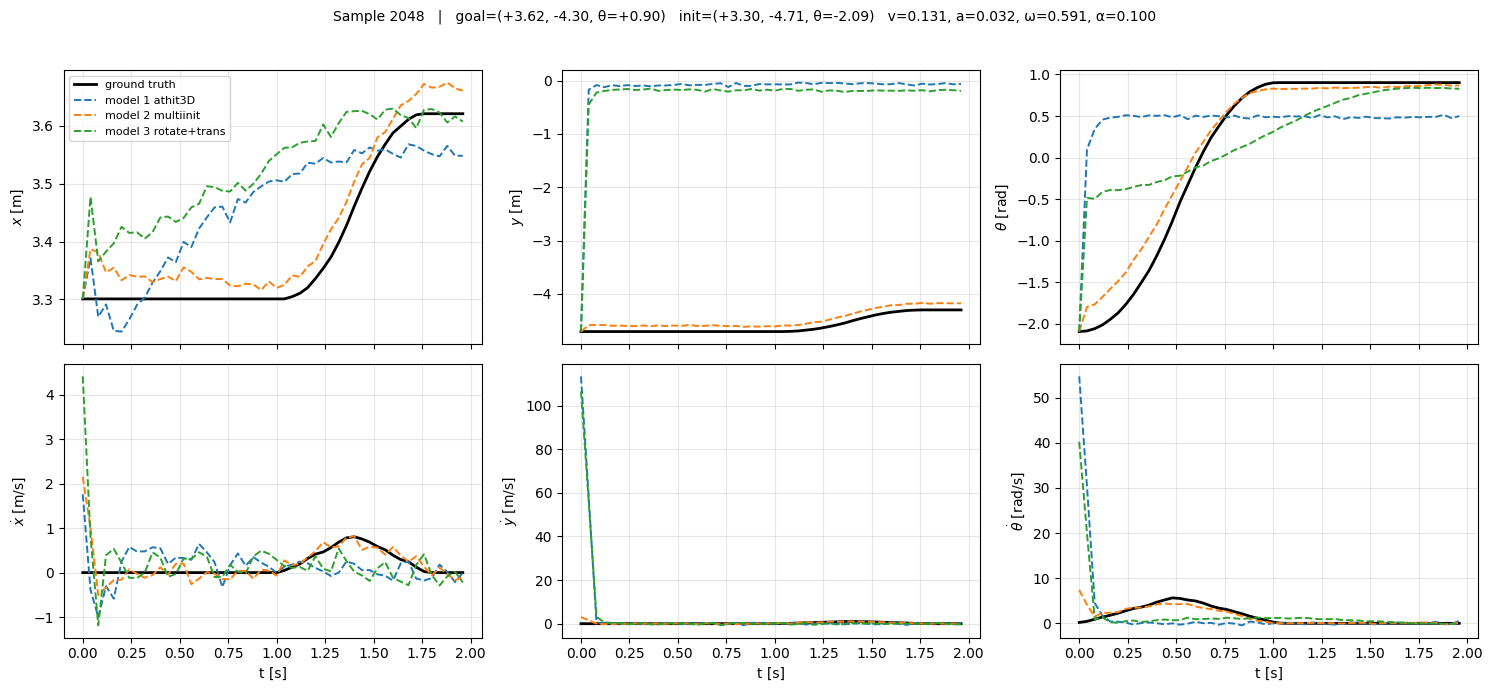

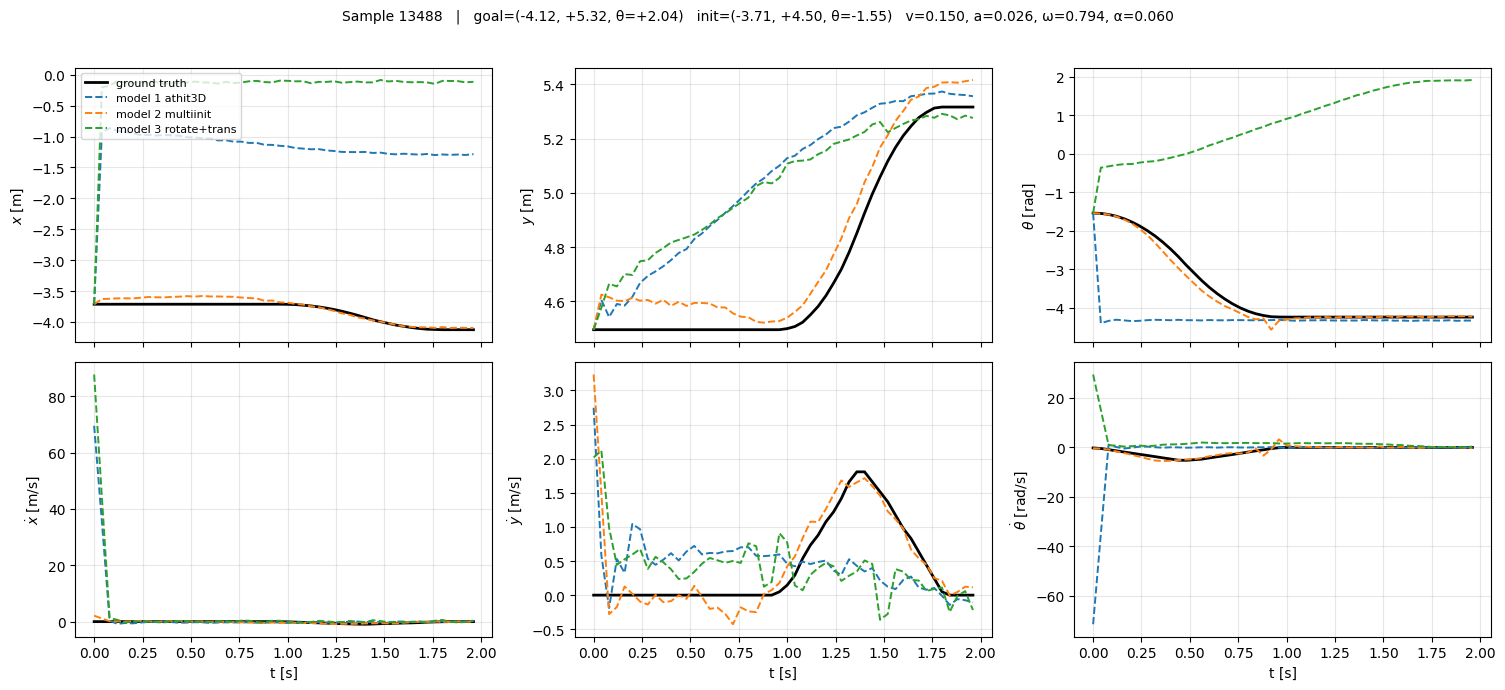

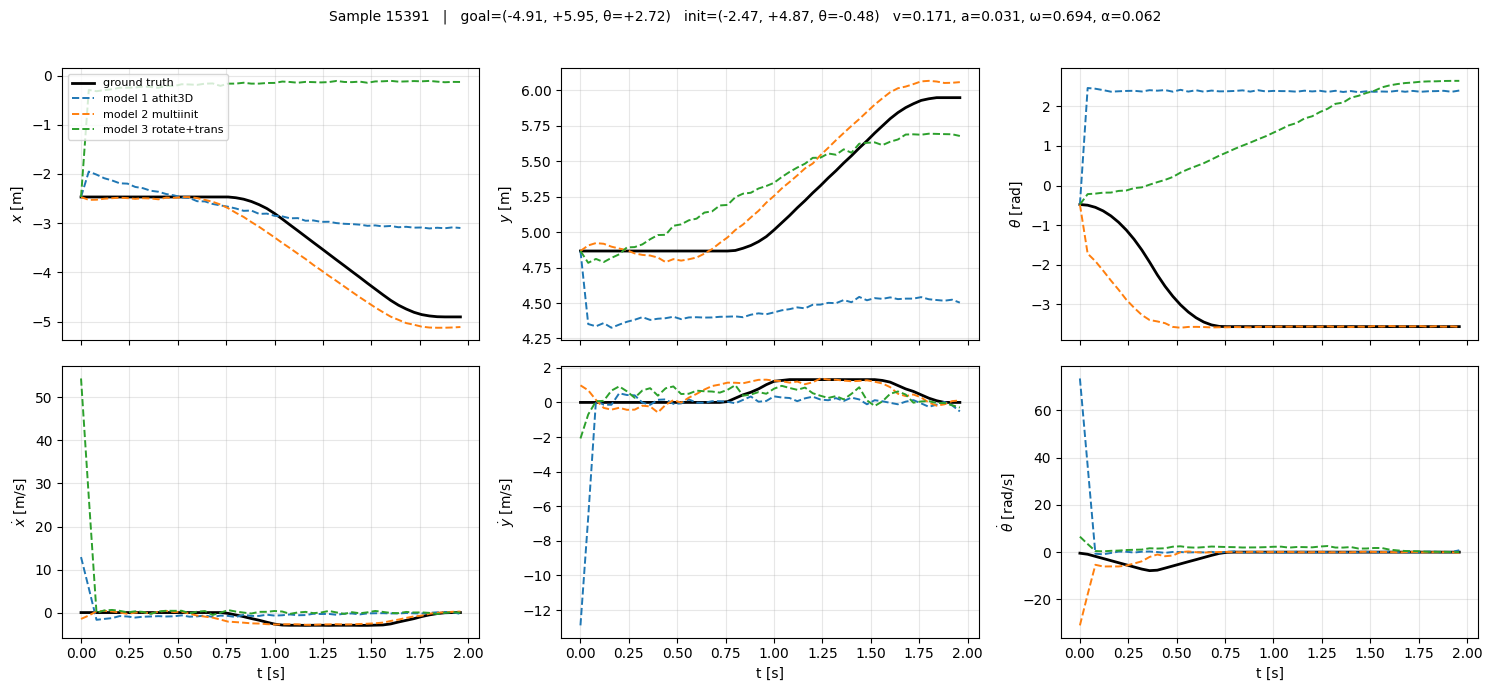

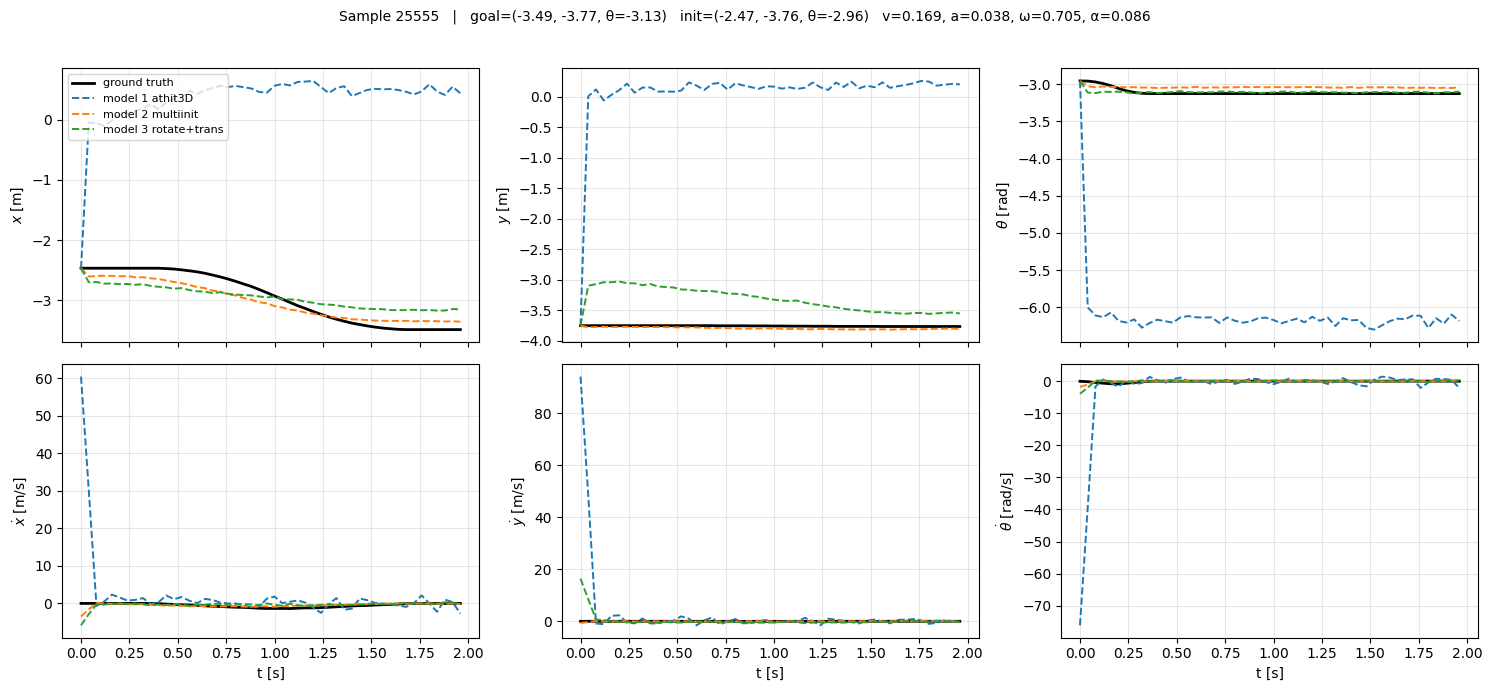

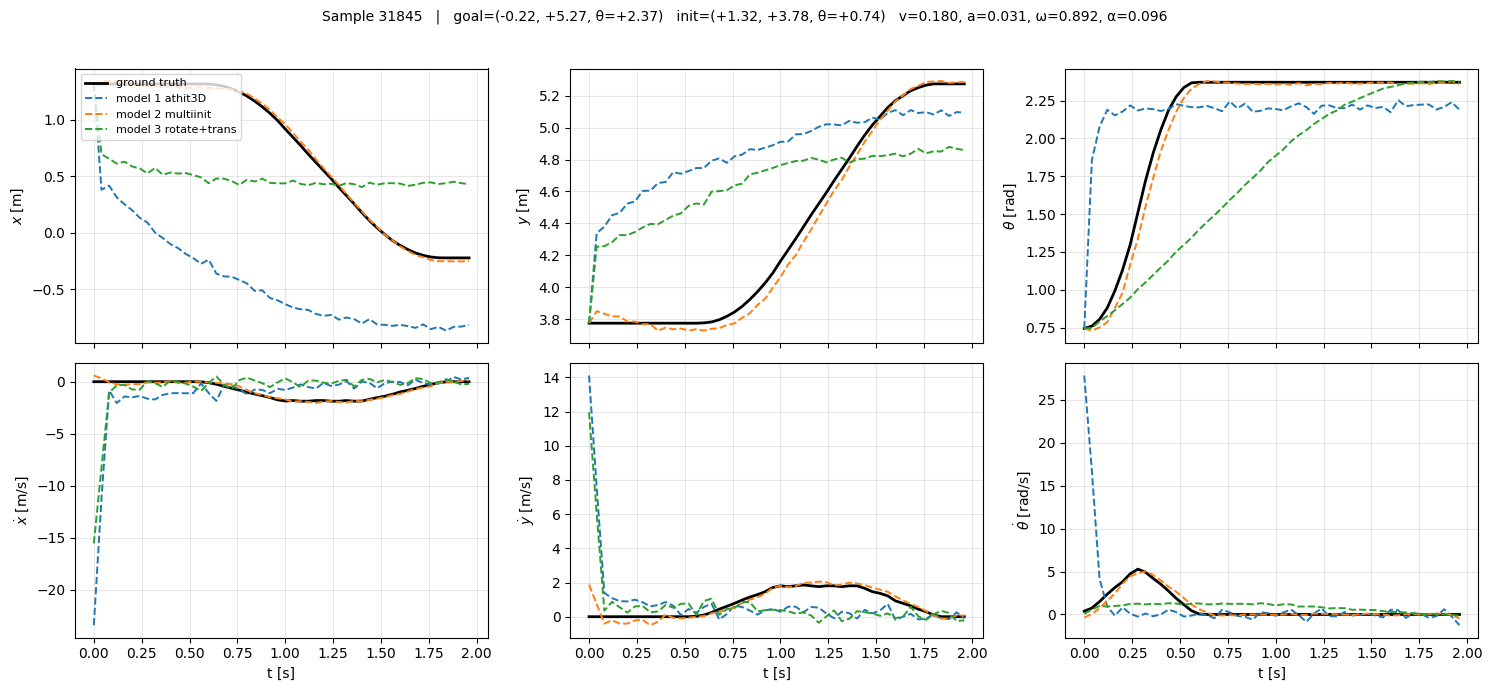

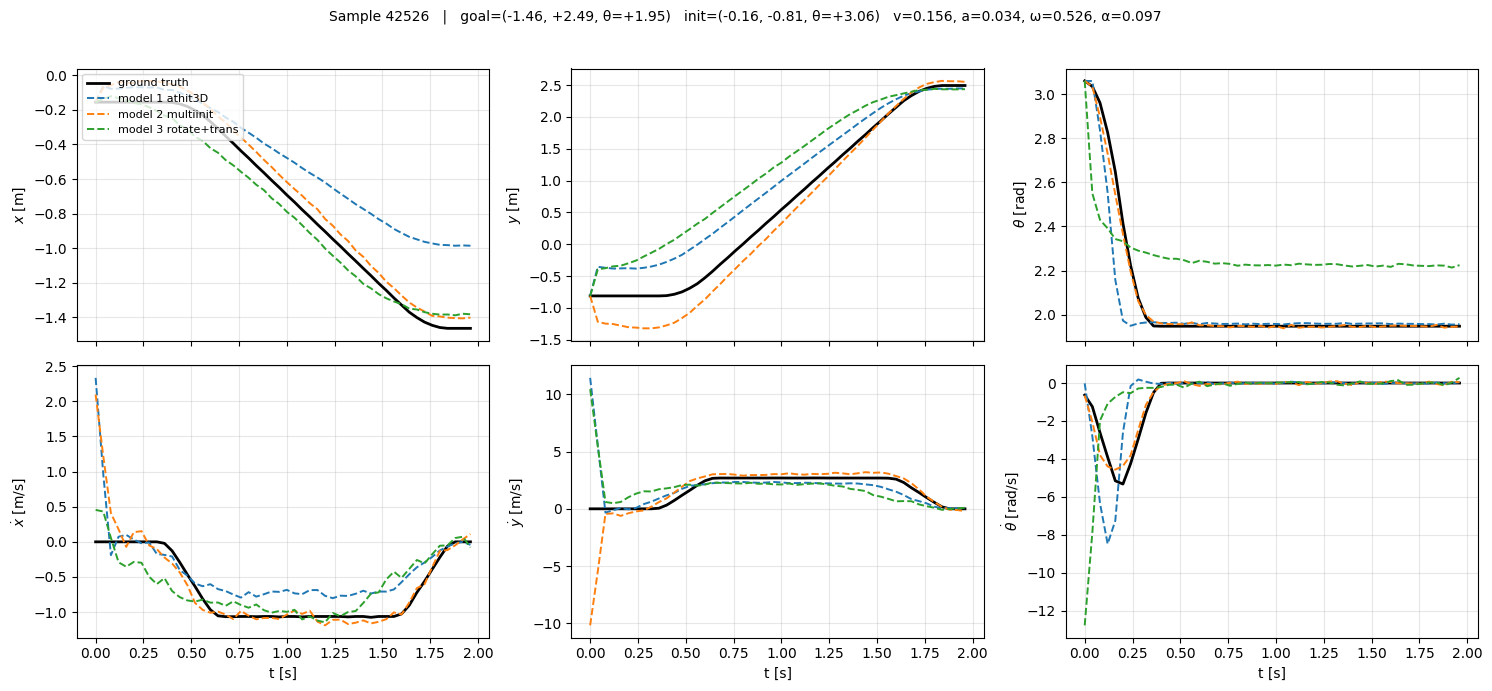

In [9]:
def plot_sample(idx: int):
    t = np.arange(ORIGINAL_LEN) * DT
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)

    pos_labels = [r'$x$ [m]', r'$y$ [m]', r'$\theta$ [rad]']
    vel_labels = [r'$\dot{x}$ [m/s]', r'$\dot{y}$ [m/s]', r'$\dot{\theta}$ [rad/s]']

    series = [
        ('ground truth', targets_np[idx], vel_gt[idx], 'black', '-',  2.0),
        ('model 1 athit3D',       out_m1[idx], vel_m1[idx], 'tab:blue',   '--', 1.4),
        ('model 2 multiinit',     out_m2[idx], vel_m2[idx], 'tab:orange', '--', 1.4),
        ('model 3 rotate+trans',  out_m3[idx], vel_m3[idx], 'tab:green',  '--', 1.4),
    ]

    for d in range(3):
        ax_p = axes[0, d]
        ax_v = axes[1, d]
        for label, pos, vel, col, ls, lw in series:
            pos_d = pos[:, d]
            if d == 2:
                pos_d = np.unwrap(pos_d)
            ax_p.plot(t, pos_d, color=col, linestyle=ls, linewidth=lw, label=label)
            ax_v.plot(t, vel[:, d], color=col, linestyle=ls, linewidth=lw)
        ax_p.set_ylabel(pos_labels[d])
        ax_v.set_ylabel(vel_labels[d])
        ax_v.set_xlabel('t [s]')
        ax_p.grid(alpha=0.3)
        ax_v.grid(alpha=0.3)

    axes[0, 0].legend(loc='upper left', fontsize=8)

    feat = features_np[idx]
    fig.suptitle(
        f'Sample {idx}   |   '
        f'goal=({feat[0]:+.2f}, {feat[1]:+.2f}, θ={feat[2]:+.2f})   '
        f'init=({feat[7]:+.2f}, {feat[8]:+.2f}, θ={feat[9]:+.2f})   '
        f'v={feat[3]:.3f}, a={feat[4]:.3f}, ω={feat[5]:.3f}, α={feat[6]:.3f}',
        fontsize=10,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


n_total = features_np.shape[0]
rng = np.random.default_rng(0)
indices = rng.choice(n_total, size=min(EVAL_N_PLOT, n_total), replace=False)
for i in sorted(indices):
    plot_sample(int(i))

## 7. Aggregate error summary

Per-channel MAE across all evaluation windows.

In [10]:
# model                        MAE x     MAE y     MAE θ
# model 1 athit3D             0.5699    0.4845    1.0179
# model 2 multiinit           0.0927    0.0906    0.1377
# model 3 rotate+trans        0.4962    0.5049    0.8467

def mae(a: np.ndarray, b: np.ndarray, theta_idx: int = 2) -> np.ndarray:
    err = a - b
    err[..., theta_idx] = np.arctan2(np.sin(err[..., theta_idx]), np.cos(err[..., theta_idx]))
    return np.abs(err).mean(axis=(0, 1))

rows = [
    ('model 1 athit3D',      mae(out_m1, targets_np)),
    ('model 2 multiinit',    mae(out_m2, targets_np)),
    ('model 3 rotate+trans', mae(out_m3, targets_np)),
]
print(f'{"model":24s}  {"MAE x":>8s}  {"MAE y":>8s}  {"MAE θ":>8s}')
for name, e in rows:
    print(f'{name:24s}  {e[0]:8.4f}  {e[1]:8.4f}  {e[2]:8.4f}')

model                        MAE x     MAE y     MAE θ
model 1 athit3D             1.4723    1.4543    0.9679
model 2 multiinit           0.1813    0.1348    0.1734
model 3 rotate+trans        0.9519    0.9939    0.8486


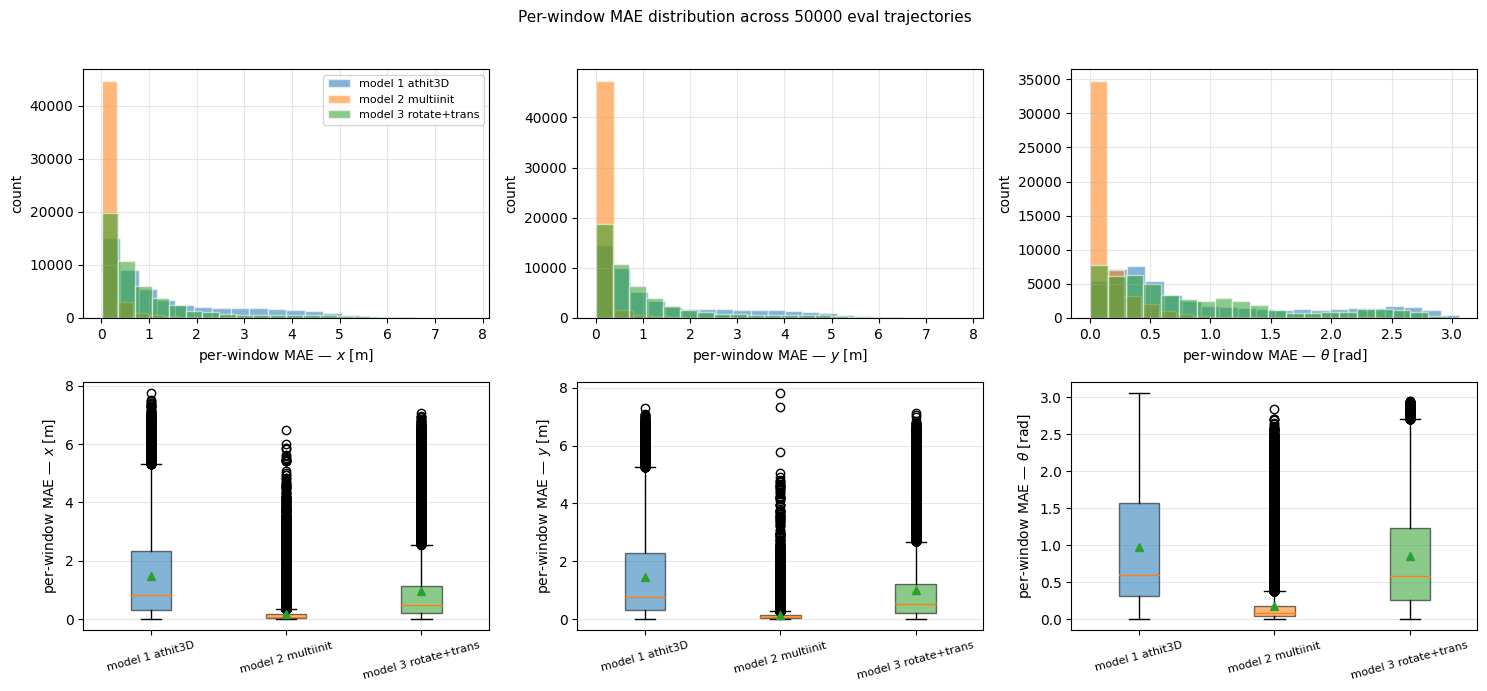

model                     channel      p50      p90      p95      max    mean     std
model 1 athit3D           x         0.8330   3.9173   4.6050   7.7524  1.4742  1.4988
model 1 athit3D           y         0.7626   3.9843   4.6703   7.2912  1.4562  1.5160
model 1 athit3D           theta     0.6006   2.4375   2.6664   3.0576  0.9698  0.8510
model 2 multiinit         x         0.0819   0.3435   0.6220   6.4909  0.1815  0.3716
model 2 multiinit         y         0.0706   0.2505   0.4169   7.8210  0.1349  0.2600
model 2 multiinit         theta     0.0805   0.4275   0.6286   2.8376  0.1737  0.2783
model 3 rotate+trans      x         0.4989   2.4788   3.9365   7.0550  0.9535  1.1930
model 3 rotate+trans      y         0.5418   2.6600   3.9944   7.1319  0.9956  1.2009
model 3 rotate+trans      theta     0.5884   2.1886   2.4791   2.9501  0.8497  0.7515


In [14]:
def per_window_mae(pred: np.ndarray, gt: np.ndarray, theta_idx: int = 2) -> np.ndarray:
    """Return (N, 3) — MAE over time for each (window, channel). Theta wrapped."""
    err = pred - gt
    err[..., theta_idx] = np.arctan2(np.sin(err[..., theta_idx]),
                                     np.cos(err[..., theta_idx]))
    return np.abs(err).mean(axis=1)


per_w = {
    'model 1 athit3D':      per_window_mae(out_m1, targets_np),
    'model 2 multiinit':    per_window_mae(out_m2, targets_np),
    'model 3 rotate+trans': per_window_mae(out_m3, targets_np),
}

channels = [(0, r'$x$ [m]'), (1, r'$y$ [m]'), (2, r'$\theta$ [rad]')]
colors   = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# Top row: per-channel histograms
for ax, (c, label) in zip(axes[0], channels):
    for (name, errs), col in zip(per_w.items(), colors):
        ax.hist(errs[:, c], bins=20, alpha=0.55, label=name, color=col, edgecolor='white')
    ax.set_xlabel(f'per-window MAE — {label}')
    ax.set_ylabel('count')
    ax.grid(alpha=0.3)
axes[0, 0].legend(loc='upper right', fontsize=8)

# Bottom row: per-channel boxplots
for ax, (c, label) in zip(axes[1], channels):
    data = [errs[:, c] for errs in per_w.values()]
    bp = ax.boxplot(data, labels=list(per_w.keys()), showmeans=True, patch_artist=True)
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.55)
    ax.set_ylabel(f'per-window MAE — {label}')
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.grid(alpha=0.3, axis='y')

fig.suptitle(f'Per-window MAE distribution across {targets_np.shape[0]} eval trajectories', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Quantile table for hard-number comparison
print(f'{"model":24s}  {"channel":7s}  {"p50":>7s}  {"p90":>7s}  {"p95":>7s}  {"max":>7s} {"mean":>7s} {"std":>7s}')
for name, errs in per_w.items():
    for c, lab in [(0, 'x'), (1, 'y'), (2, 'theta')]:
        q = np.quantile(errs[:, c], [0.5, 0.9, 0.95])
        print(f'{name:24s}  {lab:7s}  {q[0]:7.4f}  {q[1]:7.4f}  {q[2]:7.4f}  {errs[:, c].max():7.4f} {errs[:, c].mean():7.4f} {errs[:, c].std():7.4f}')


In [12]:
print(per_w.keys())

dict_keys(['model 2 multiinit'])


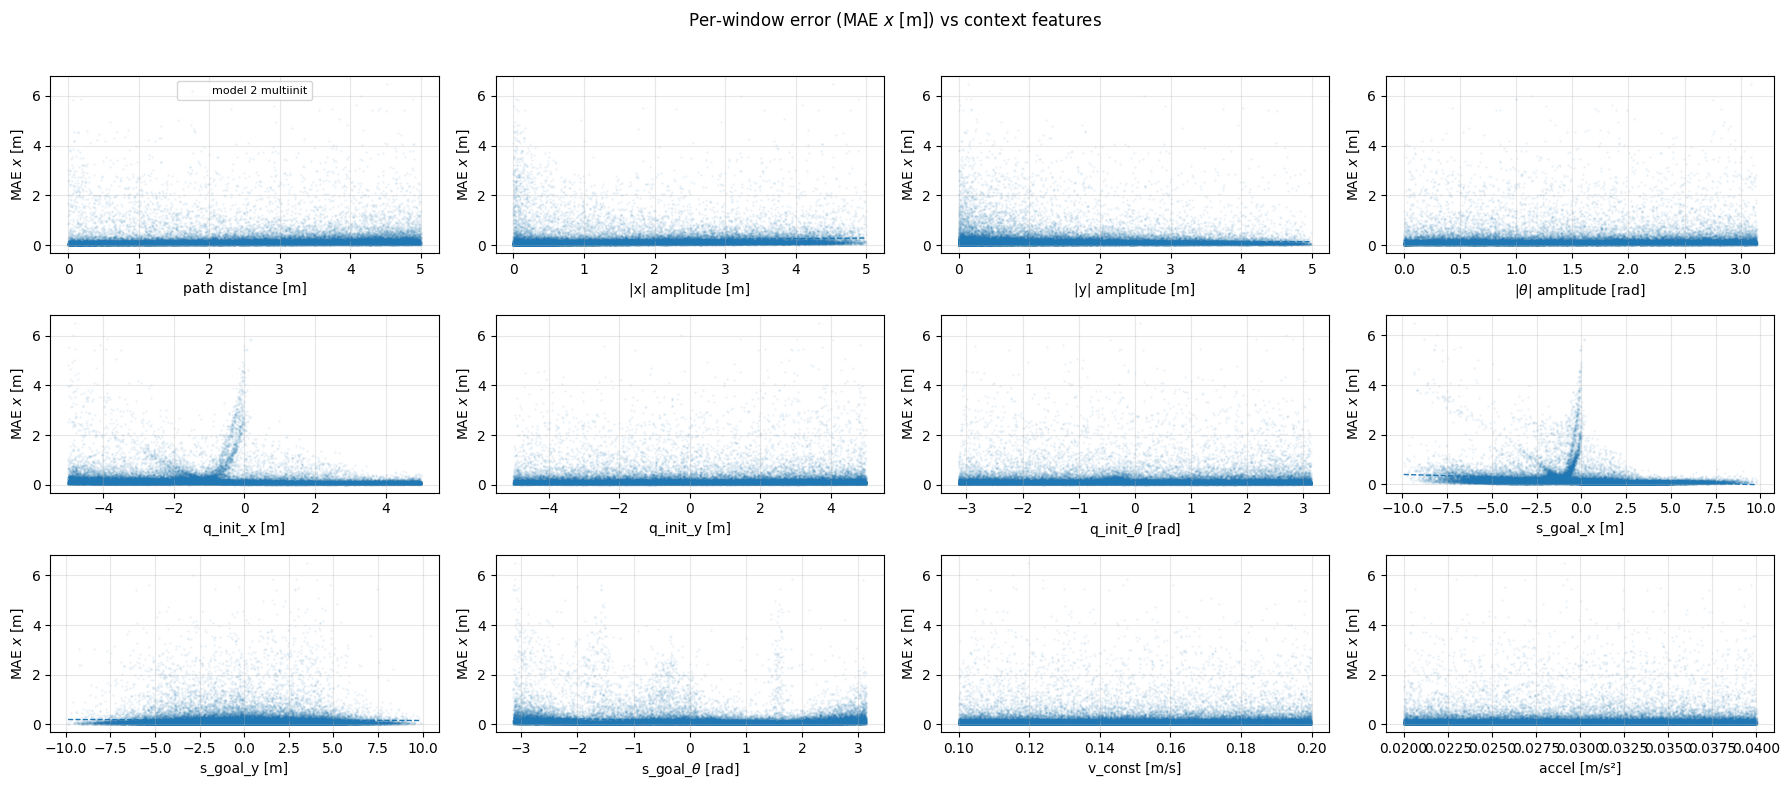

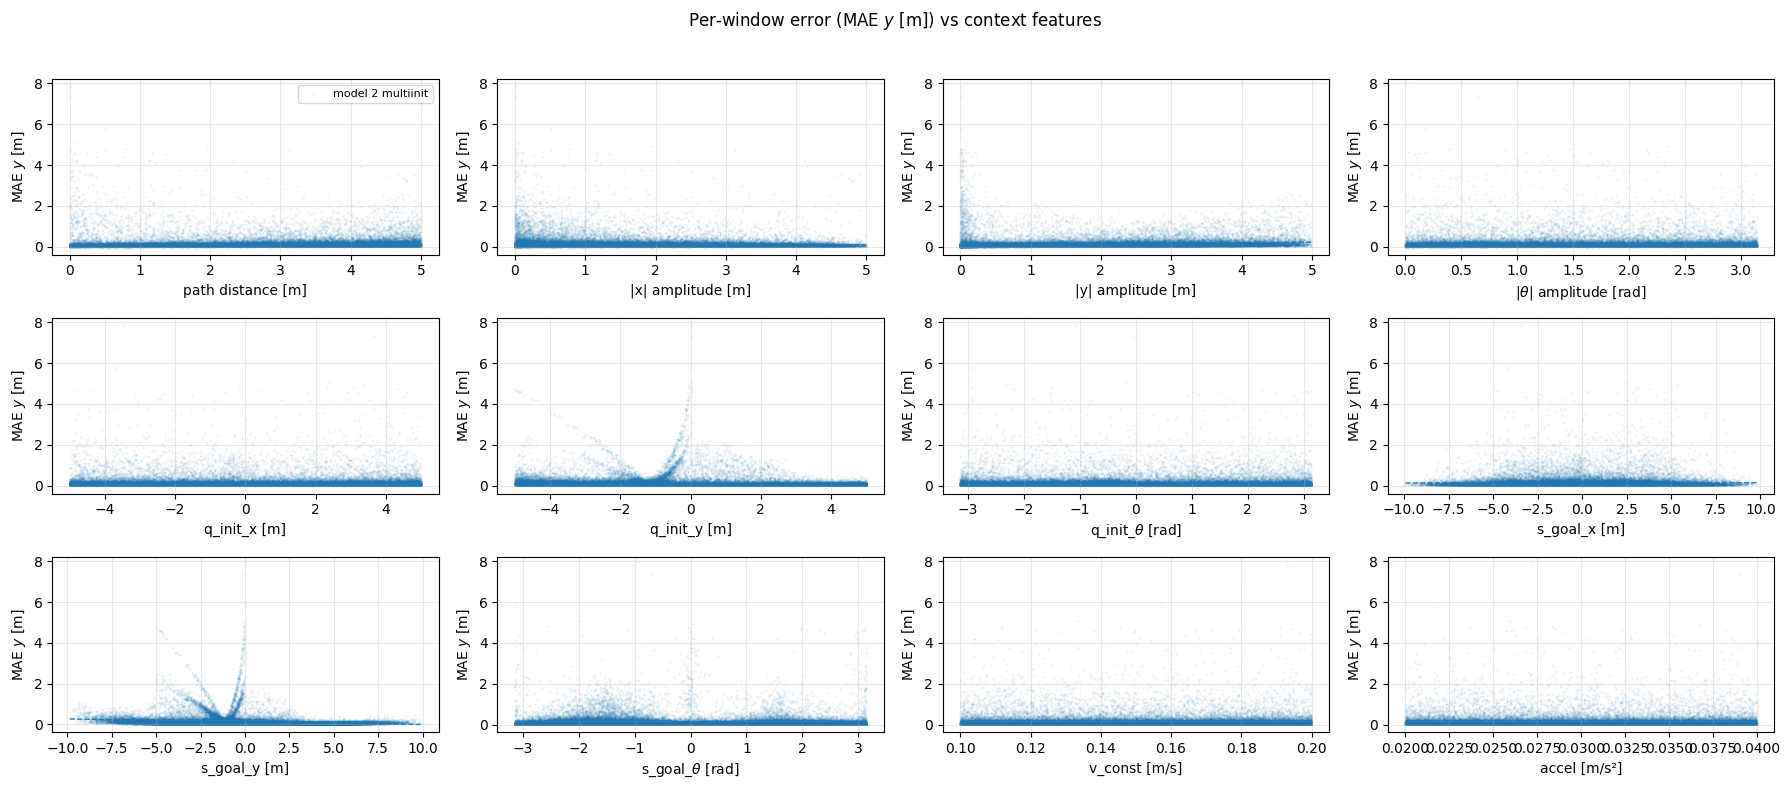

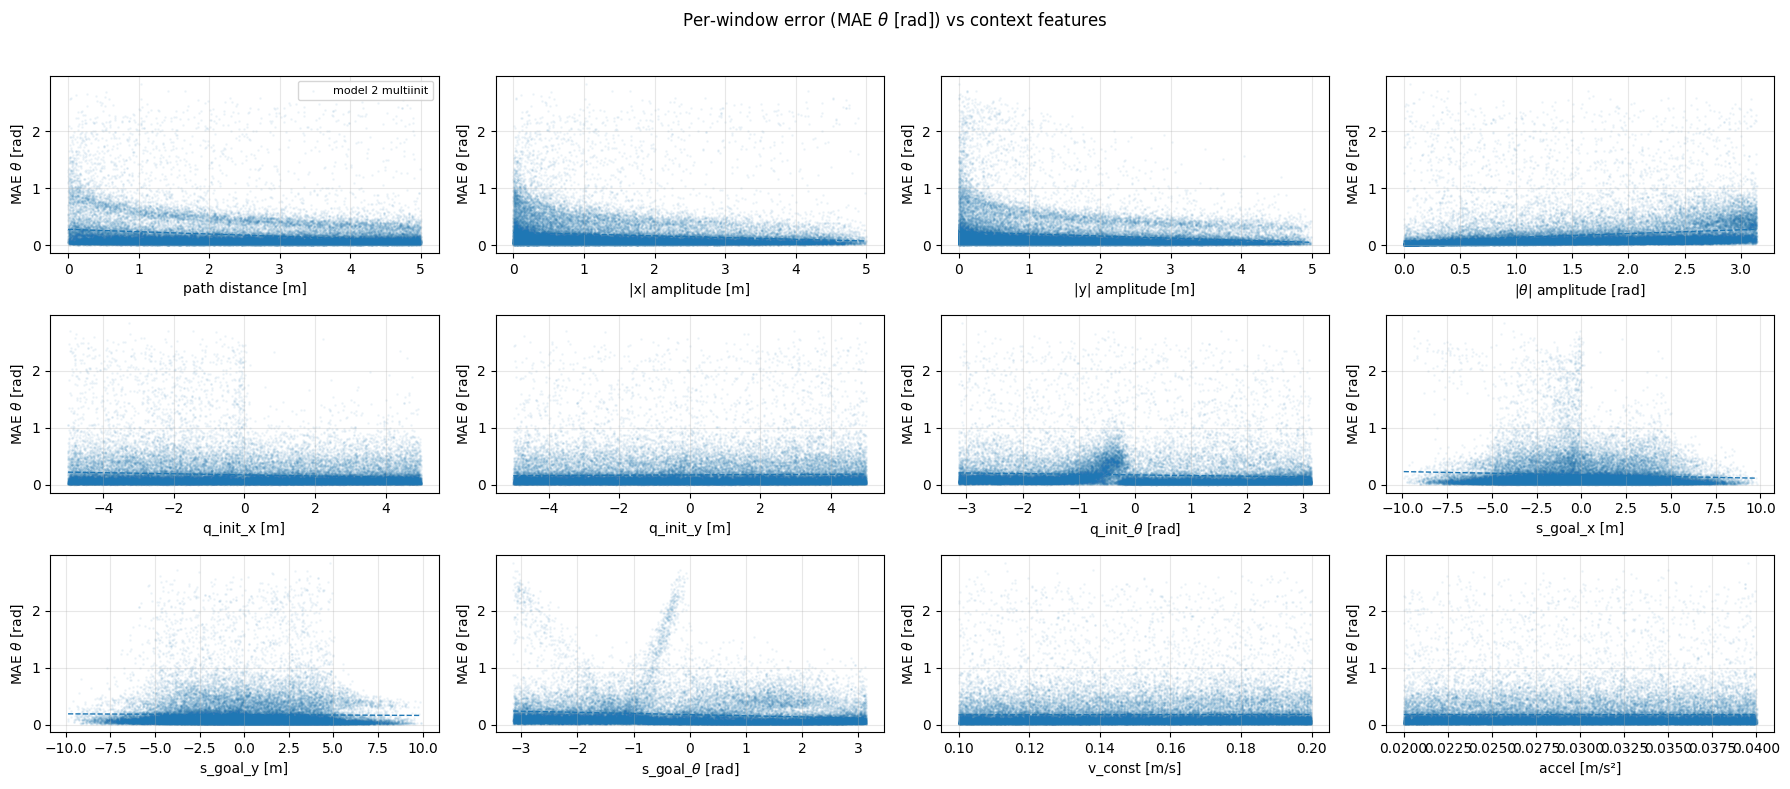

model                     channel  path distance   |x| amplitude   |y| amplitude   |$\theta$| amp    q_init_x [m]    q_init_y [m]  q_init_$\theta    s_goal_x [m]    s_goal_y [m]  s_goal_$\theta   v_const [m/s]    accel [m/s²]  omega_const [r  alpha_const [r
model 2 multiinit         x                +0.052          +0.103          -0.051          -0.001          -0.187          +0.039          +0.001          -0.198          -0.019          -0.099          -0.002          +0.003          -0.004          -0.002
model 2 multiinit         y                +0.060          -0.060          +0.126          -0.013          +0.007          -0.135          -0.004          +0.007          -0.183          -0.066          +0.003          -0.003          -0.002          -0.002
model 2 multiinit         theta            -0.210          -0.138          -0.170          +0.216          -0.101          +0.029          -0.075          -0.074          -0.018          -0.131          +0.008          -0.002 

/tmp/ipykernel_1152038/3869055948.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


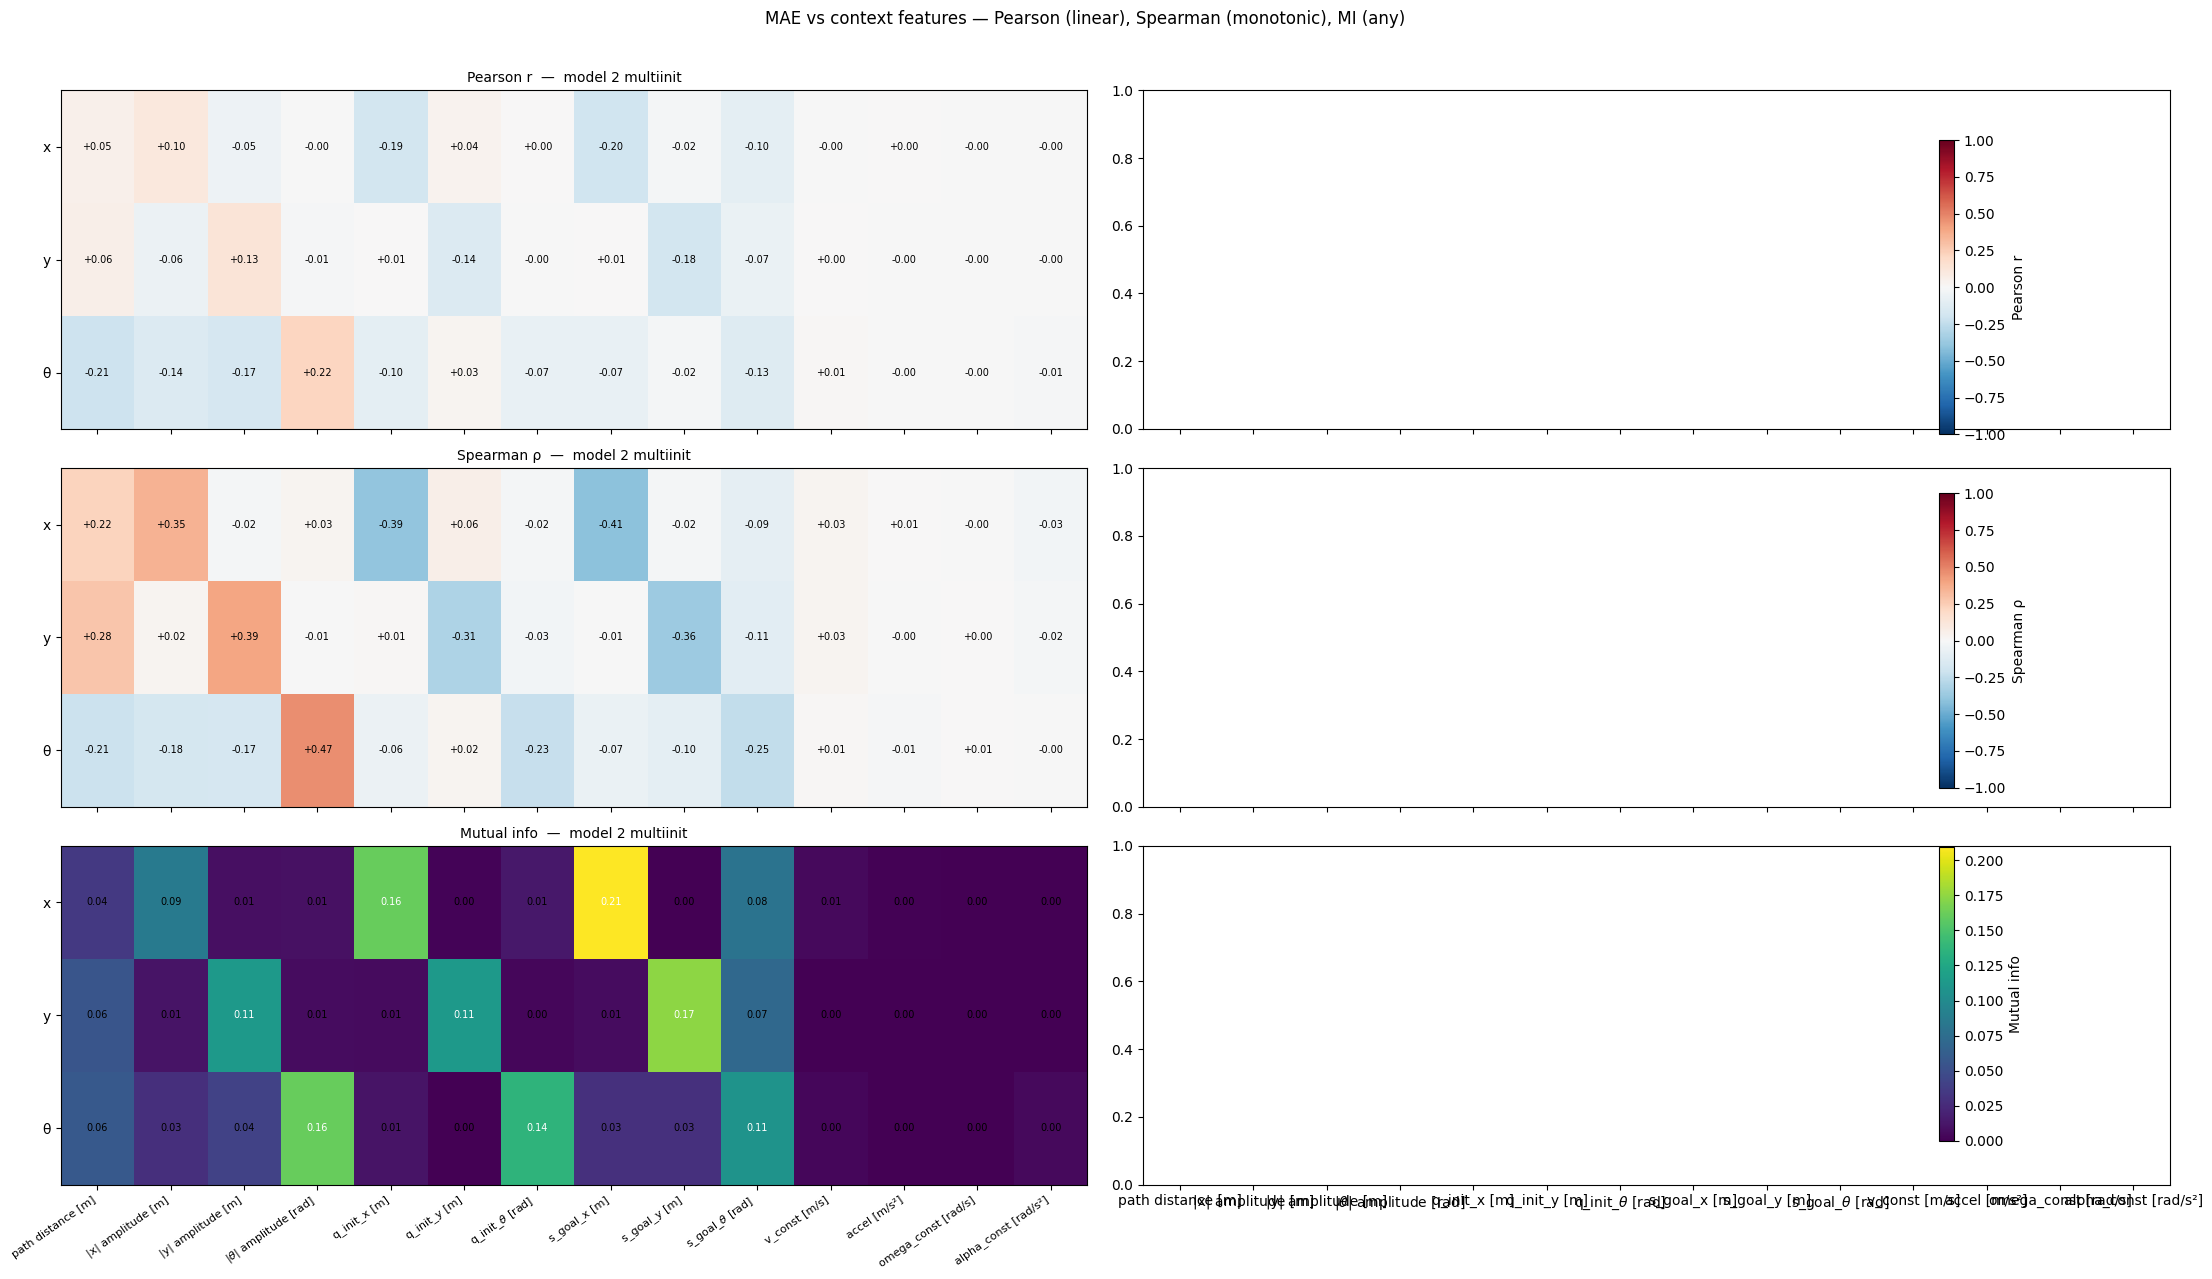

In [13]:
# ─── Error vs context features ─────────────────────────────────────────────
# Reuses per_w (per-window MAE per channel) computed above. For each of the
# 8 context features below we plot scatter + linear trend per model, and
# print the Pearson r per (model, feature, channel).

# Derived context variables
goal_x      = features_np[:, 0]
goal_y      = features_np[:, 1]
goal_theta  = features_np[:, 2]
v_const     = features_np[:, 3]
accel       = features_np[:, 4]
omega_const = features_np[:, 5]
alpha_const = features_np[:, 6]
q_x         = features_np[:, 7]
q_y         = features_np[:, 8]
q_theta     = features_np[:, 9]

path_dist = np.hypot(goal_x - q_x, goal_y - q_y)
x_amp     = np.abs(goal_x - q_x)
y_amp     = np.abs(goal_y - q_y)
theta_diff = goal_theta - q_theta
theta_amp = np.abs(np.arctan2(np.sin(theta_diff), np.cos(theta_diff)))

variables = [
    ('path distance [m]',       path_dist),
    ('|x| amplitude [m]',       x_amp),
    ('|y| amplitude [m]',       y_amp),
    (r'|$\theta$| amplitude [rad]', theta_amp),
    ('q_init_x [m]',            q_x),
    ('q_init_y [m]',            q_y),
    (r'q_init_$\theta$ [rad]',  q_theta),
    ('s_goal_x [m]',            goal_x),
    ('s_goal_y [m]',            goal_y),
    (r's_goal_$\theta$ [rad]',  goal_theta),
    ('v_const [m/s]',           v_const),
    ('accel [m/s²]',            accel),
    ('omega_const [rad/s]',     omega_const),
    ('alpha_const [rad/s²]',    alpha_const),
]

channel_labels = [(0, r'MAE $x$ [m]'),
                  (1, r'MAE $y$ [m]'),
                  (2, r'MAE $\theta$ [rad]')]


def plot_error_vs_features(channel_idx: int, channel_label: str):
    fig, axes = plt.subplots(3, 4, figsize=(18, 8))
    fig.suptitle(f'Per-window error ({channel_label}) vs context features', fontsize=12)
    for ax, (label, var) in zip(axes.flat, variables):
        for (name, errs), col in zip(per_w.items(), colors):
            if name == 'model 3 rotate+trans' or name == 'model 1 athit3D':
                continue
            err = errs[:, channel_idx]
            ax.scatter(var, err, color=col, alpha=0.05, s=1, label=name)
            if len(var) >= 2 and np.std(var) > 0:
                slope, intercept = np.polyfit(var, err, 1)
                xx = np.linspace(var.min(), var.max(), 50)
                ax.plot(xx, slope * xx + intercept,
                        color=col, linestyle='--', linewidth=1, alpha=0.99)
        ax.set_xlabel(label)
        ax.set_ylabel(channel_label)
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc='best', fontsize=8)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



for c, lab in channel_labels:
    plot_error_vs_features(c, lab)

# ─── Pearson correlation table ─────────────────────────────────────────────
print(f'{"model":24s}  {"channel":7s}  ' + '  '.join(f'{lab[:14]:>14s}' for lab, _ in variables))
for name, errs in per_w.items():
    for c, lab in [(0, 'x'), (1, 'y'), (2, 'theta')]:
        row = []
        for _, var in variables:
            if np.std(var) > 0 and np.std(errs[:, c]) > 0:
                r = float(np.corrcoef(var, errs[:, c])[0, 1])
            else:
                r = float('nan')
            row.append(f'{r:>+14.3f}')
        print(f'{name:24s}  {lab:7s}  ' + '  '.join(row))


# ─── Pearson r heatmap (3 panels, one per model) ──────────────────────────
# Extended feature set: 8 derived vars + init pose + goal pose components.
hm_variables = variables + [
    ('q_init_x [m]',            q_x),
    ('q_init_y [m]',            q_y),
    (r'q_init_$\theta$ [rad]',  q_theta),
    ('s_goal_x [m]',            goal_x),
    ('s_goal_y [m]',            goal_y),
    (r's_goal_$\theta$ [rad]',  goal_theta),
]
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression

# `variables` already contains all 14 features — your previous hm_variables
# was duplicating q_init_*/s_goal_*. Use `variables` directly.
hm_variables = variables
var_labels   = [lab for lab, _ in hm_variables]
channel_short = ['x', 'y', 'θ']


def compute_matrices(fn):
    """Return list of (3, V) matrices — one per model — using metric fn."""
    out = []
    for _, errs in per_w.items():
        m = np.zeros((3, len(hm_variables)))
        for ci in range(3):
            for vi, (_, var) in enumerate(hm_variables):
                if np.std(var) > 0 and np.std(errs[:, ci]) > 0:
                    m[ci, vi] = fn(var, errs[:, ci])
                else:
                    m[ci, vi] = np.nan
        out.append(m)
    return out


pearson_mats  = compute_matrices(lambda v, e: float(np.corrcoef(v, e)[0, 1]))
spearman_mats = compute_matrices(lambda v, e: float(spearmanr(v, e).statistic))
mi_mats       = compute_matrices(
    lambda v, e: float(mutual_info_regression(v.reshape(-1, 1), e, random_state=0)[0])
)

mi_vmax = float(np.nanmax([np.nanmax(m) for m in mi_mats]))

rows_spec = [
    # (title,        matrices,       cmap,      vmin, vmax,    fmt,      text_thresh)
    ('Pearson r',    pearson_mats,   'RdBu_r',  -1,   1,       '{:+.2f}', 0.5),
    ('Spearman ρ',   spearman_mats,  'RdBu_r',  -1,   1,       '{:+.2f}', 0.5),
    ('Mutual info',  mi_mats,        'viridis', 0,    mi_vmax, '{:.2f}',  0.5 * mi_vmax),
]

fig, axes = plt.subplots(3, 2, figsize=(22, 13), sharex=True)
for r_idx, (title, mats, cmap, vmin, vmax, fmt, color_thresh) in enumerate(rows_spec):
    for c_idx, (name, m) in enumerate(zip(per_w.keys(), mats)):
        ax = axes[r_idx, c_idx]
        im = ax.imshow(m, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(hm_variables)))
        ax.set_xticklabels(var_labels, rotation=35, ha='right', fontsize=8)
        ax.set_yticks(range(3))
        ax.set_yticklabels(channel_short)
        ax.set_title(f'{title}  —  {name}', fontsize=10)
        for ci in range(3):
            for vi in range(len(hm_variables)):
                val = m[ci, vi]
                if np.isfinite(val):
                    pos = val if title == 'Mutual info' else abs(val)
                    ax.text(vi, ci, fmt.format(val),
                            ha='center', va='center', fontsize=7,
                            color='white' if pos > color_thresh else 'black')
    fig.colorbar(im, ax=axes[r_idx].tolist(),
                 fraction=0.015, pad=0.02, label=title)

fig.suptitle('MAE vs context features — Pearson (linear), Spearman (monotonic), MI (any)',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


